(sec:dim_reduction)=

# Dimensionality Reduction

So far, in supervised learning, we have considered problems with data of the form $(x_i, y_i)_{i=1}^N$, where the goal is to model the relationship between features $x$ and labels $y$. We now turn to techniques that can uncover patterns when no labels are available, which is the setting of unsupervised learning. In this chapter, we focus on dimensionality reduction: finding a low-dimensional representation of the data while preserving as much of the original information as possible.

## Theoretical Foundations

### Principal Component Analysis (PCA)

The idea of PCA is to find a lower-dimensional coordinate system in which each data point is represented by only $k$ instead of $d$ features. The transformation into this new coordinate system is defined by a projection matrix $\bm{V}_k \in \mathbb{R}^{d \times k}$. Multiplying the data matrix $\bm{X} \in \mathbb{R}^{N \times d}$[^1] by $\bm{V}_k$ yields a new matrix $\bm{Z}_k \in \mathbb{R}^{N \times k}$, which contains the data in the new coordinate system:

$$
\bm{Z}_k 
= 
\bm{X} \bm{V}_k
$$

[^1]: We do not need to add an extra column of ones to $\bm{X}$ here, since there are no weights or biases to fit.

The optimal projection matrix $\bm{V}_k$ can be chosen by requiring that the reconstruction of $\bm{X}$ from $\bm{Z}_k$ should be as close as possible to the original data. Recall from {ref}`sec:singular_value_decomposition` that the low-rank approximation of a matrix given by its compact SVD,

$$
\bm{X}_k 
= 
\bm{U}_k \bm{\Sigma}_k \bm{V}_k^T 
= 
\sum_{i=1}^k \sigma_i \vec{u}_i \vec{v}_i^T
$$

is the best possible rank-$k$ approximation of $\bm{X}$ in the Frobenius norm. Therefore, the projection matrix $\bm{V}_k$ we are looking for is given by the first $k$ columns of $\bm{V}$, the right singular vectors in the SVD of $\bm{X}$. These vectors are called the **principal components**.

We can also use the fact that the columns of $\bm{V}$ correspond to the eigenvectors of the covariance matrix $\bm{X}^T \bm{X}$:

$$
\bm{X}^T \bm{X} 
=
(\bm{U} \bm{\Sigma} \bm{V}^T)^T \bm{U} \bm{\Sigma} \bm{V}^T
=
\bm{V} \bm{\Sigma} \underbrace{\bm{U}^T \bm{U}}_{=1\kern-0.25em\text{l}} \bm{\Sigma} \bm{V}^T
=
\bm{V} \bm{\Sigma}^2 \bm{V}^T
$$

The eigenvalues of $\bm{X}^T \bm{X}$, which are the squared singular values $\sigma_i$ of $\bm{X}$, measure the contribution of each principal component. After normalisation, these contributions are called the **explained variances**.

:::{note} Mathematical details
:class: dropdown

Start from the compact SVD:

$$
\bm{X}_k 
= 
\bm{U}_k \bm{\Sigma}_k \bm{V}_k^T
$$

Projecting the rank-$k$ approximation of $\bm{X}$ onto the first $k$ columns of $\bm{V}$ yields a matrix with $k$ columns, which we call $\bm{Z}_k$:

$$
\bm{X}_k \bm{V}_k 
= 
\bm{U}_k \bm{\Sigma}_k \underbrace{\bm{V}_k^T \bm{V}_k}_{=1\kern-0.25em\text{l}} 
= 
\bm{U}_k \bm{\Sigma}_k
= 
\bm{Z}_k
$$

Now consider the full SVD of $\bm{X}$:

$$
\bm{X} 
= 
\bm{U} \bm{\Sigma} \bm{V}^T
$$

Projecting the full data matrix onto $\bm{V}_k$ yields the same low-dimensional representation, because the product $\bm{V}^T \bm{V}_k$ selects the first $k$ coordinate directions:

$$
\bm{X} \bm{V}_k 
= 
\bm{U} \bm{\Sigma} \bm{V}^T \bm{V}_k 
= 
\bm{U} \bm{\Sigma}
\begin{pmatrix}
1_1    &        &        & 0 \\
       & \ddots &        &   \\
       &        & 1_k    &   \\
0      &        &        & 0
\end{pmatrix}
=
\bm{U}_k \bm{\Sigma}_k
=
\bm{Z}_k
$$

The Eckart-Young-Mirsky theorem states that the reconstruction

$$
\bm{X}_k 
= 
\bm{Z}_k \bm{V}^T_k 
$$

is the best possible rank-$k$ approximation of $\bm{X}$ in the Frobenius norm.

:::

### Further Methods

Because PCA is a **linear** dimensionality reduction method, it can only find flat directions through the original feature space. This is often useful, but it may miss curved or more complicated structures in the data.

**t-SNE** (*t-distributed stochastic neighbor embedding*) is a nonlinear method that aims to preserve local neighborhoods: points that are close in the original feature space should also be close in the low-dimensional map. It converts pairwise distances into neighborhood probabilities and then moves points in the low-dimensional map until these probabilities are similar. t-SNE is often used for two-dimensional visualisation, especially to explore whether data points form clusters.

**UMAP** (*uniform manifold approximation and projection*) is another nonlinear method that focuses on preserving neighborhood relationships. It first builds a graph connecting nearby points in the original feature space and then lays out this graph in fewer dimensions. UMAP is often faster than t-SNE and can preserve more large-scale structure, but like t-SNE, it is mainly used as an exploratory visualisation tool rather than as a direct replacement for PCA in mathematical modelling workflows.

## Implementation

The implementation of PCA is straightforward and follows the steps derived above:

1. Center the data matrix $\bm{X}$ by subtracting the mean of each feature from the data points. This ensures that PCA measures the variance of the data rather than its offset from the origin.
2. Compute the eigenvalues and eigenvectors of the covariance matrix $\bm{X}^T \bm{X}$.
3. Sort the eigenvectors by decreasing eigenvalue, if they are not already sorted.
4. Project the data onto the first $k$ eigenvectors.

We start by implementing the constructor, where we initialise placeholder attributes for the column means, the projection matrix $\bm{V}_k$, and the explained variances $\sigma^2_i$.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
class PrincipalComponentAnalysis:
    def __init__(self, k=2):
        self.k = k
        self.mean = None
        self.components = None
        self.explained_variance = None

Following the steps outlined above, the `fit` method uses [`np.cov`](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) to compute the covariance matrix $\bm{X}^T \bm{X}$.

Note that `np.linalg.eigh` returns the eigenvalues and eigenvectors in ascending order. We therefore take the **last** $k$ columns with `[:, -self.k:]` and reverse their order with `[:, ::-1]`.

In [24]:
    def fit(self, X):
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Compute the covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # Compute the eigenvalues and eigenvectors (ascending order)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Store the top k eigenvectors (principal components)
        self.components = eigenvectors[:, -self.k:][:, ::-1]
        
        # Calculate the explained variances of all principal components
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        
        return self

Because the data have no associated labels, we do not need a `predict` method. Instead, we implement the projection onto the principal components in the `transform` method. Here, we reuse the mean from the `fit` method so that new data are projected using the same centering convention as the training data.

In [25]:
    def transform(self, X):
        # Project the data onto the first k principal components
        X_centered = X - self.mean
        return X_centered @ self.components
    
    def fit_transform(self, X):
        # Fit the model and return the transformed data
        return self.fit(X).transform(X)

:::{tip} Full implementation
:class: dropdown

The complete PCA class is shown below, including explanatory docstrings.

```python
class PrincipalComponentAnalysis:
    """A simple principal component analysis model.

    The model centers the training data, computes the covariance matrix,
    and uses its leading eigenvectors as principal component directions.
    New data are centered with the training mean before projection.

    Parameters
    ----------
    k : int
        Number of principal components to keep.

    Attributes
    ----------
    k : int
        Number of principal components stored on the model.
    mean : 1d-array or None
        Feature-wise mean of the training data. This is used to center data
        before projection.
    components : 2d-array or None
        Matrix whose columns are the first k principal component directions.
    explained_variance : 1d-array or None
        Fraction of total variance explained by each principal component.
    """

    def __init__(self, k=2):
        """Initialise the model hyperparameter and placeholder attributes."""
        self.k = k
        self.mean = None
        self.components = None
        self.explained_variance = None

    def fit(self, X):
        """Fit the principal component directions from the training data."""
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        self.components = eigenvectors[:, -self.k:][:, ::-1]
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        return self

    def transform(self, X):
        """Project data onto the fitted principal component directions."""
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        """Fit the model and return the projected training data."""
        self.fit(X)
        return self.transform(X)
```

:::

In [26]:
class PrincipalComponentAnalysis:
    """A simple principal component analysis model.

    The model centers the training data, computes the covariance matrix,
    and uses its leading eigenvectors as principal component directions.
    New data are centered with the training mean before projection.

    Parameters
    ----------
    k : int
        Number of principal components to keep.

    Attributes
    ----------
    k : int
        Number of principal components stored on the model.
    mean : 1d-array or None
        Feature-wise mean of the training data. This is used to center data
        before projection.
    components : 2d-array or None
        Matrix whose columns are the first k principal component directions.
    explained_variance : 1d-array or None
        Fraction of total variance explained by each principal component.
    """

    def __init__(self, k=2):
        """Initialise the model hyperparameter and placeholder attributes."""
        self.k = k
        self.mean = None
        self.components = None
        self.explained_variance = None

    def fit(self, X):
        """Fit the principal component directions from the training data."""
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        self.components = eigenvectors[:, -self.k:][:, ::-1]
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        return self

    def transform(self, X):
        """Project data onto the fitted principal component directions."""
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        """Fit the model and return the projected training data."""
        self.fit(X)
        return self.transform(X)

## Application

Let us now apply PCA to a problem from current research in chemistry. In an ongoing project, we are interested in how solvent molecules interact with polycyclic aromatic hydrocarbons (PAHs). We therefore performed simulations that yield the geometries of 18 conformational isomers of quinoline ($\mathrm{C_9H_7N}$) with chloroform ($\mathrm{CHCl}_3$), shown in the following figure.

![Conformers of Quinoline and Chloroform](/assets/figures/data_driven_modelling/Conformers.pdf)

To characterise these geometries, we constructed 500 features from distances and angles between pairs and triplets of atoms in different parts of the molecule. The data can be downloaded here: {download}`/assets/data/data_driven_modelling/conformers.csv`.

In [27]:
df = pd.read_csv('conformers.csv')
df.head()

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_490,dim_491,dim_492,dim_493,dim_494,dim_495,dim_496,dim_497,dim_498,dim_499
0,6.484415,6.512751,7.209587,7.813031,5.598746,5.197558,5.413828,6.115553,6.833008,4.616440,...,79.389142,90.481568,92.006819,106.034017,86.401973,94.009786,107.630235,108.536841,128.041265,100.727465
1,6.341733,6.320978,6.514812,7.882226,5.540070,5.166577,5.183634,5.243819,6.842093,4.540198,...,80.086785,86.878528,79.817664,103.500907,85.057806,93.447891,102.805004,94.384389,124.929265,98.862557
2,6.411415,6.333558,6.474849,7.895143,5.549329,5.188125,5.193691,5.240514,6.852813,4.550481,...,79.809273,87.000291,80.310442,103.580702,85.226705,93.735987,103.027782,94.549625,125.100377,99.115631
3,4.674616,3.747897,4.394519,4.724341,2.681700,4.055627,3.666855,4.653286,4.778704,2.663429,...,58.761196,50.015181,46.434323,67.348889,38.306088,63.065673,49.510637,45.541052,62.730972,37.552920
4,4.653232,3.704199,4.825569,4.124101,2.692573,4.586104,3.830451,4.674146,4.785078,2.752492,...,50.719738,48.803035,70.339445,48.139592,37.974847,51.597802,46.569381,67.486438,42.158927,36.742968


Given the small number of data points, the large number of features makes it difficult to reason about the data or fit a model without risking severe overfitting. We therefore apply PCA to reduce the dimensionality from $d = 500$ to $k = 2$. To do this, we create an instance of the `PrincipalComponentAnalysis` class and call its `fit_transform` method with the data matrix as input.

In [28]:
X = df.values
pca = PrincipalComponentAnalysis(k=2)
Z = pca.fit_transform(X)
print(Z.shape)

(18, 2)


We can now plot the data in the low-dimensional space spanned by the first two principal components. The [`plt.annotate`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html) function allows us to label each data point with its corresponding index from the figure above.

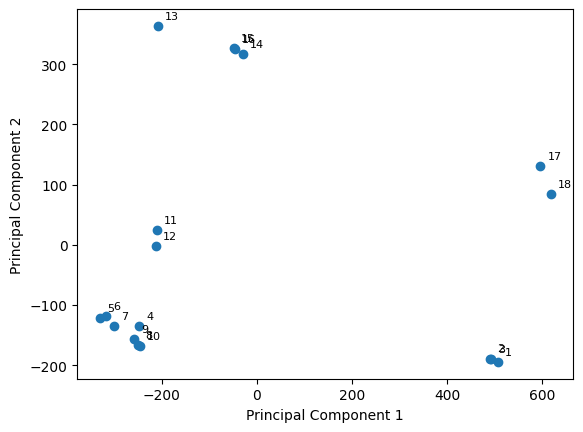

In [29]:
plt.plot(Z[:, 0], Z[:, 1], 'o')
for i, (x, y) in enumerate(zip(Z[:, 0], Z[:, 1])):
    plt.annotate(str(i+1), (x, y), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

By visually comparing the distribution of points in the low-dimensional space with the conformer geometries, we see that the first two principal components capture a basic underlying structure of the data. This is evident from the fact that similar geometries are close together in the low-dimensional space, and it can be quantified by analysing the **explained variances** $\sigma^2_i$ of the principal components.

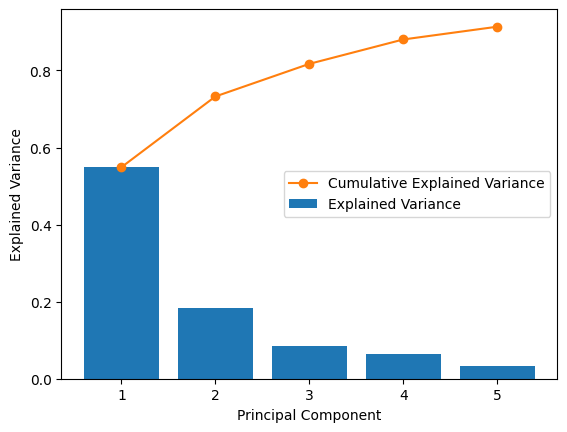

In [30]:
n = 5

plt.bar(range(1, n + 1), pca.explained_variance[:n], color='tab:blue', label='Explained Variance')
plt.plot(range(1, n + 1), np.cumsum(pca.explained_variance[:n]), 'o-', c='tab:orange', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.legend()
plt.show()

:::{tip} An equivalent perspective on PCA

PCA identifies the directions in feature space along which the data vary the most. Directions with large variance receive large eigenvalues and are kept as leading principal components, while directions with little variation contribute less to the low-dimensional representation. Features that are nearly constant across all data points therefore have little influence on the principal components, because they contribute little to the overall variance.

:::

## Self-Study Questions

1. Why is the data matrix centered before applying PCA?
2. Under which condition on the singular values $\sigma_i$ can we fully recover the original data from the first $k$ principal components?
3. How and why do we reverse the order of the eigenvectors before selecting the leading $k$ components?

In [31]:
# Convert Z to a DataFrame and write to CSV
Z_df = pd.DataFrame(Z, columns=[f'PC{i+1}' for i in range(Z.shape[1])])
Z_df.to_csv('conformers_pca.csv', index=False)